In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from best_frame_fix import *

In [2]:
ROOT_DIR = Path(r"C:\Users\sar31\Documents\GitHub\flm_tem_alignment")
DEFAULT_DIR = ROOT_DIR / "jey_002_g3_l8"
flm_path =  DEFAULT_DIR / "Composite-stacks-JEY002-G3-L8.tif"
tem_path = DEFAULT_DIR / "JEY002_G3_L8_1950x_t-13.tif"
flm_pixel_nm = 121.0
tem_pixel_nm = 6.9
pad_factor = 1

In [3]:
flm_stack = io.imread(str(flm_path))
img_tem = io.imread(str(tem_path))
tem_h, tem_w = img_tem.shape[:2]
tem_height_flm = (tem_h * tem_pixel_nm) / flm_pixel_nm
tem_width_flm  = (tem_w * tem_pixel_nm) / flm_pixel_nm

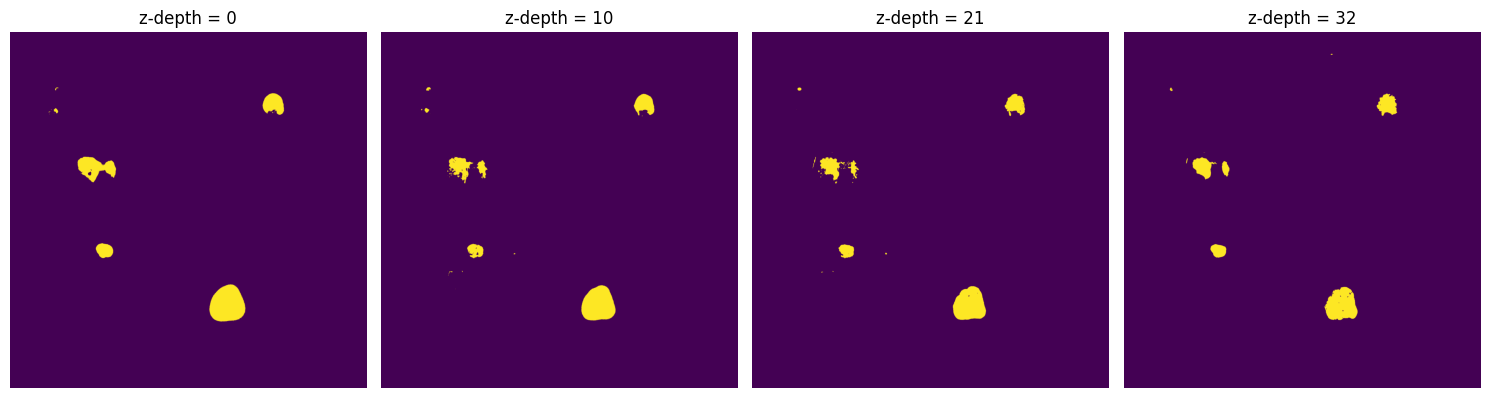

In [4]:
# show the ROI masks that are found by using Otsu thresholding for a few frames to demonstrate what has been found and that the problem are
n = len(flm_stack)
indices = np.linspace(0, n-1, 4, dtype=int)  # 4 evenly spaced indices including ends

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, i in zip(axes, indices):
    roi_mask = get_roi_mask(flm_stack[i])
    ax.imshow(roi_mask)
    ax.set_title(f'z-depth = {i}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# showing example for 15th frame
frame_idx = 15
img_flm = flm_stack[frame_idx]
roi_mask = get_roi_mask(img_flm)
bboxes = get_bbox_from_roi_mask(roi_mask)

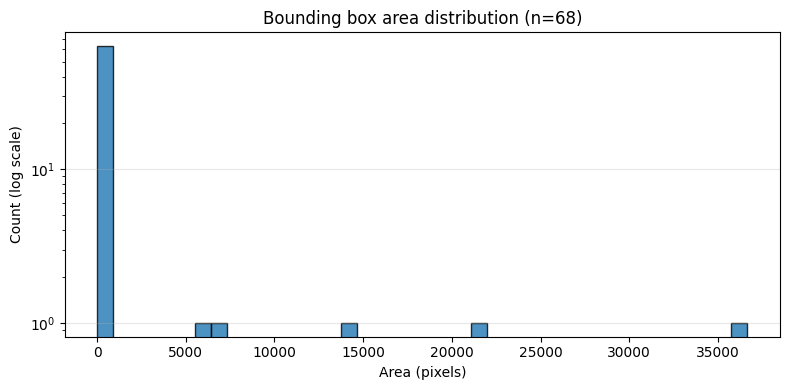

array([  432, 14364,   575,     1,    12,     6,     6, 21114,     6,
           4,     1,  6180,     1,     1,    16,    48,     4,     2,
           9,    12,    16,    18,    16,    28,     2,     2,     4,
           1,     1,    12,    20,    80,     2,     2,    72,    48,
           2,     1,    20,     2,    35,    20,    90,   144,    30,
           9,    36,     1,    20,     1,     9,     9,     1,    25,
           1,     9,  7128,     1,    70,     2,     1,    99,   225,
           1,     1, 36666,     1,     1])

In [6]:
# showing that most of the areas are very small and not needed
plot_bbox_area_hist(bboxes, bins=40, log_scale=True)

In [7]:
# target one of the larger area
target_idx = 29

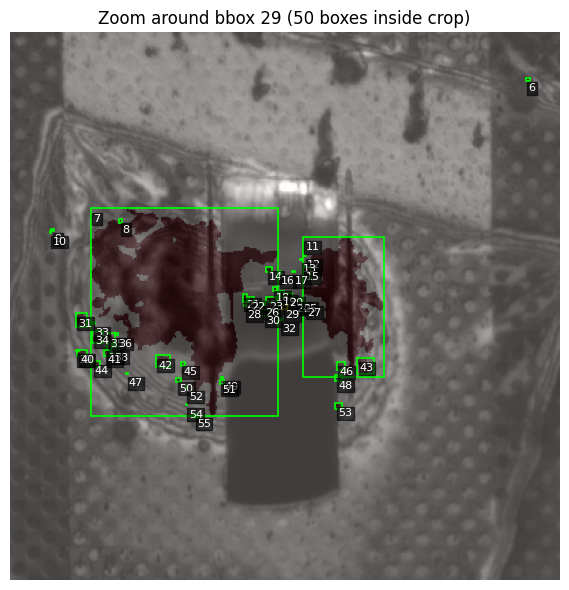

In [8]:
# this show the boxes up close to see that there are a lot of them that are really small 
# these boxes need to be filter out as they are noise
# this specific example also show the need for bigger bounding boxes witing tem_height_flm range to be merged
show_zoom(img_flm, roi_mask, bboxes, target_idx=target_idx, pad=200)

In [9]:
filted_and_merged_bboxes = filter_and_merge_bboxes(bboxes, tem_height_flm, tem_width_flm)

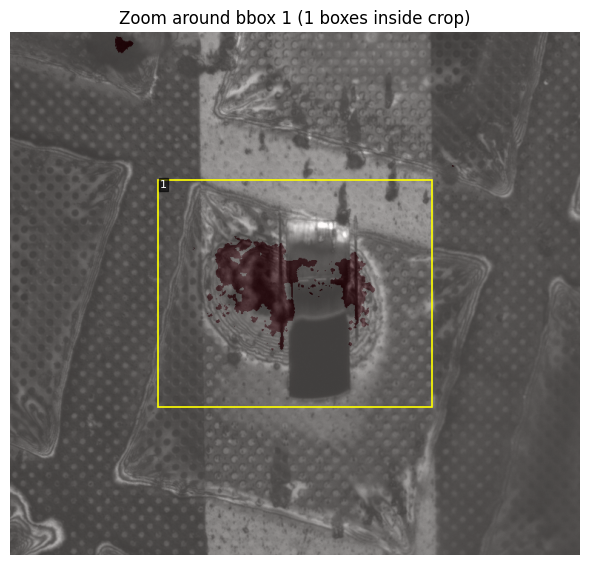

In [10]:
target_idx = 1
show_zoom(img_flm, roi_mask, filted_and_merged_bboxes, target_idx=target_idx, pad=200)

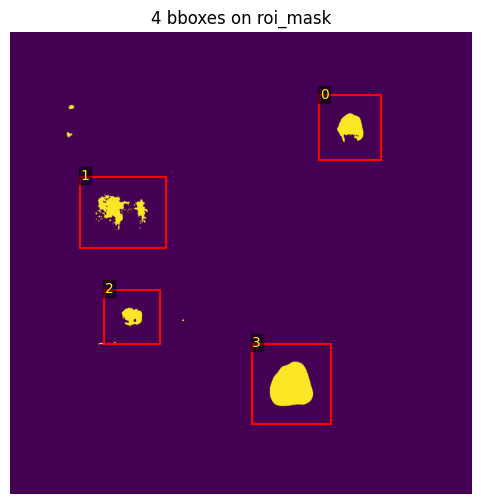

In [12]:
plot_bbox_over_roi_mask(roi_mask, filted_and_merged_bboxes)